In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os
import cv2
import random
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [9]:
DATASET_PATH = "/content/drive/My Drive/RoadShield-AI/dataset/pothole_dataset"

TRAIN_IMAGES = os.path.join(DATASET_PATH, "train/images")
TRAIN_LABELS = os.path.join(DATASET_PATH, "train/labels")

VALID_IMAGES = os.path.join(DATASET_PATH, "valid/images")
VALID_LABELS = os.path.join(DATASET_PATH, "valid/labels")

TEST_IMAGES = os.path.join(DATASET_PATH, "test/images")
TEST_LABELS = os.path.join(DATASET_PATH, "test/labels")

In [10]:
def count_images(folder):
    return len([
        f for f in os.listdir(folder)
        if f.endswith((".jpg", ".png", ".jpeg"))
    ])

print("Training :", count_images(TRAIN_IMAGES))
print("Validation :", count_images(VALID_IMAGES))
print("Testing :", count_images(TEST_IMAGES))

Training : 3105
Validation : 273
Testing : 174


In [11]:
def count_labels(folder):
    return len([
        f for f in os.listdir(folder)
        if f.endswith(".txt")
    ])

print("Train Labels :", count_labels(TRAIN_LABELS))
print("Validation Labels :", count_labels(VALID_LABELS))
print("Test Labels :", count_labels(TEST_LABELS))

Train Labels : 3105
Validation Labels : 273
Test Labels : 174


In [12]:
missing = []

for image in os.listdir(TRAIN_IMAGES):

    label = image.rsplit(".",1)[0] + ".txt"

    if not os.path.exists(os.path.join(TRAIN_LABELS,label)):
        missing.append(image)

print("Missing Labels:",len(missing))

print(missing[:10])

Missing Labels: 0
[]


In [13]:
widths=[]
heights=[]

for image in os.listdir(TRAIN_IMAGES):

    path=os.path.join(TRAIN_IMAGES,image)

    img=cv2.imread(path)

    if img is not None:
        h,w,_=img.shape
        widths.append(w)
        heights.append(h)

print("Minimum Width:",min(widths))
print("Maximum Width:",max(widths))

print("Minimum Height:",min(heights))
print("Maximum Height:",max(heights))

Minimum Width: 416
Maximum Width: 640
Minimum Height: 352
Maximum Height: 416


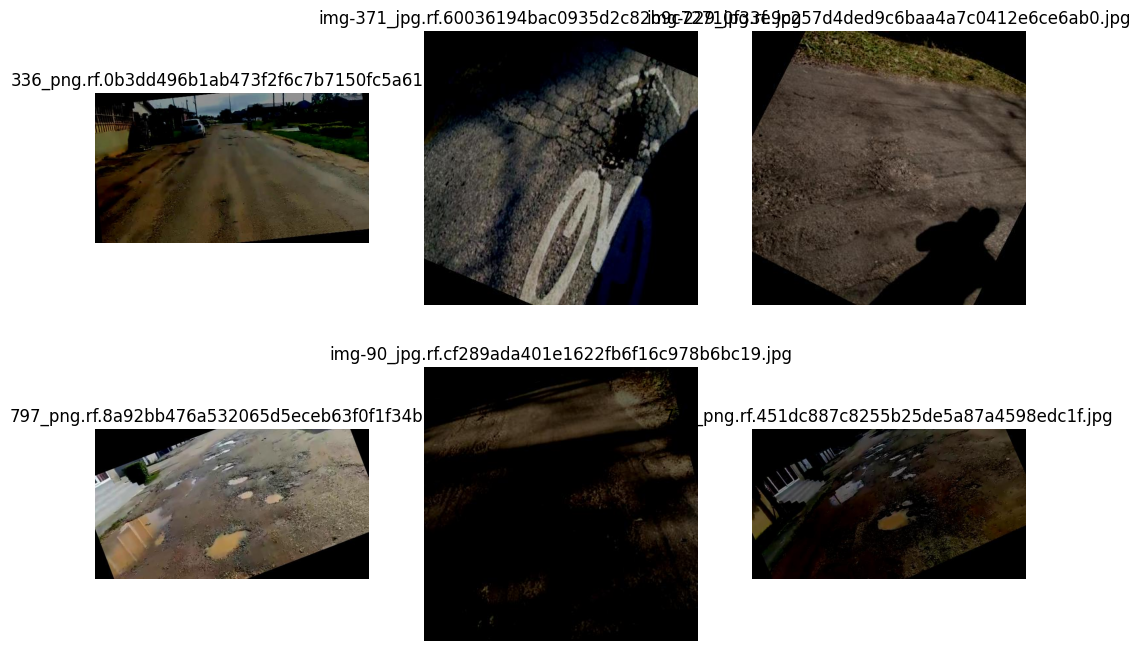

In [14]:
fig,axes=plt.subplots(2,3,figsize=(12,8))

images=random.sample(os.listdir(TRAIN_IMAGES),6)

for ax,img_name in zip(axes.flat,images):

    img=cv2.imread(os.path.join(TRAIN_IMAGES,img_name))

    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    ax.imshow(img)

    ax.set_title(img_name)

    ax.axis("off")

plt.show()

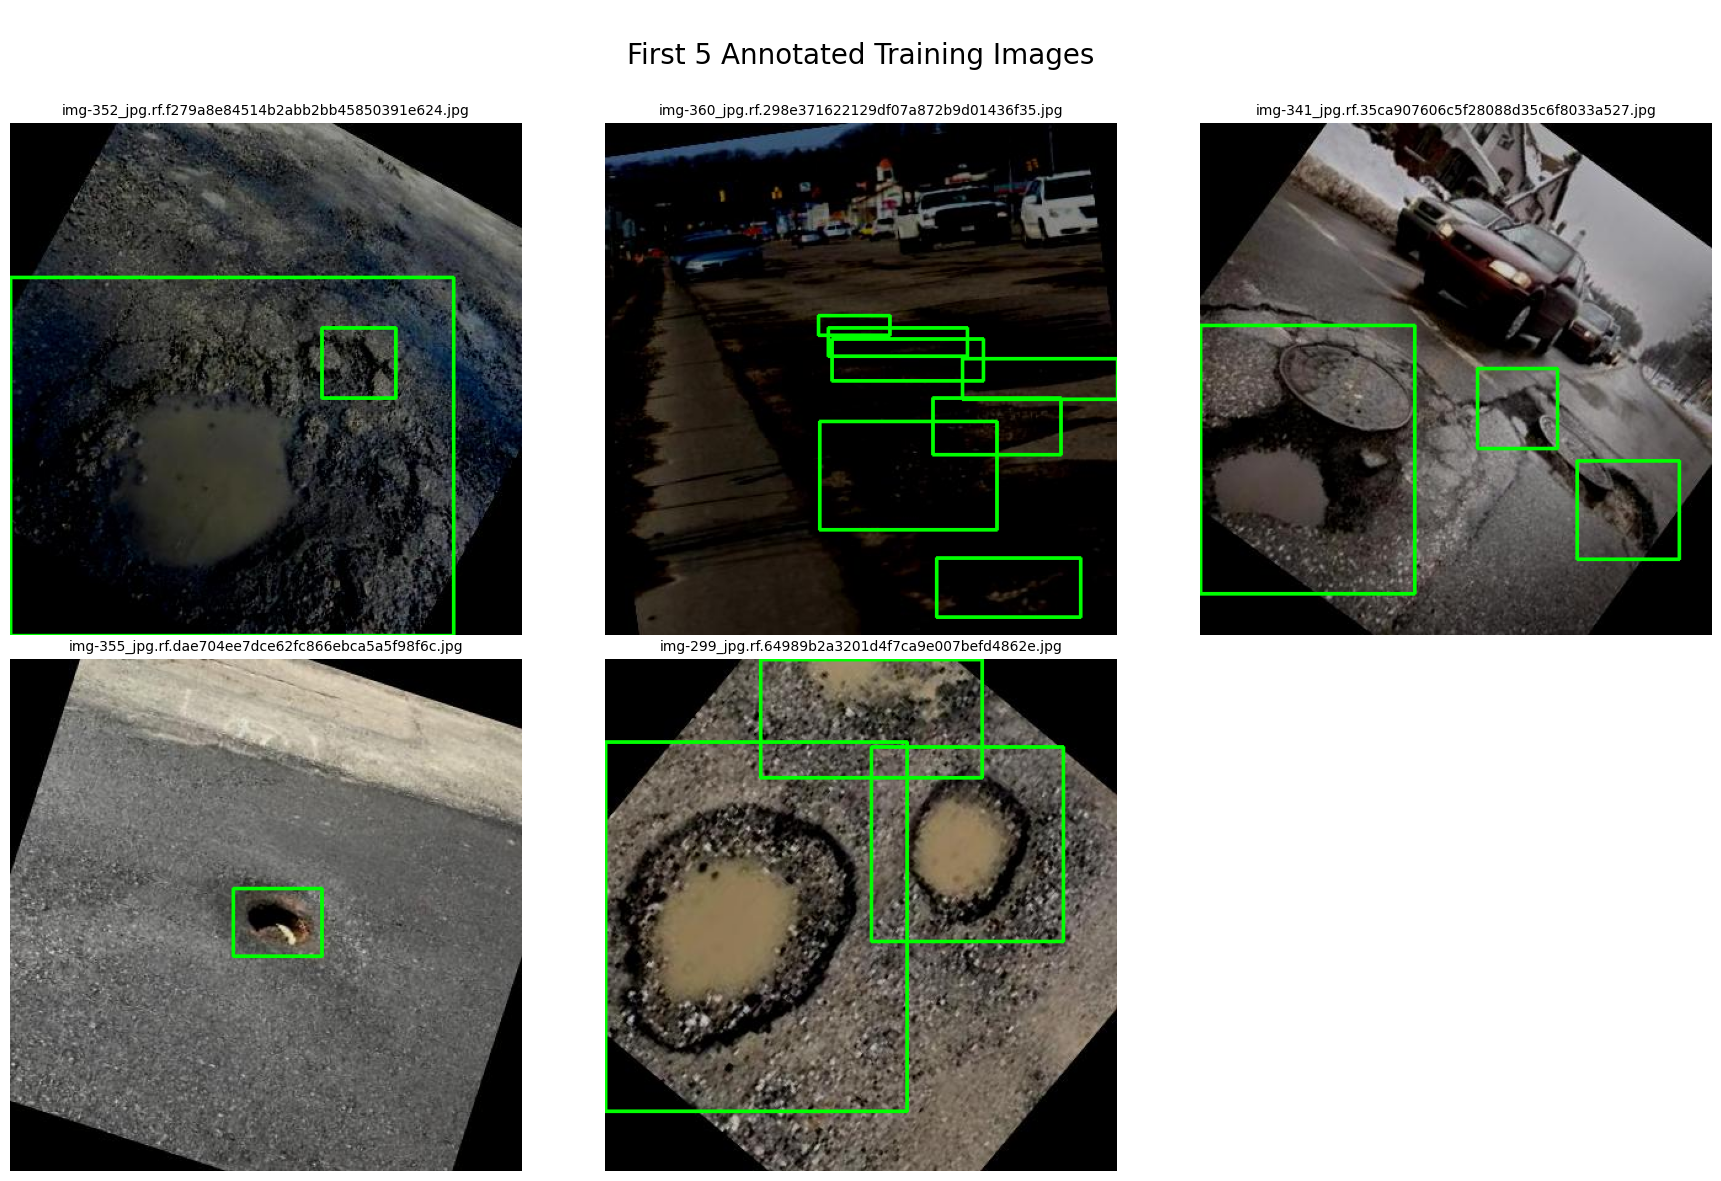

In [15]:
import cv2
import matplotlib.pyplot as plt
import os

dataset_path = "/content/drive/MyDrive/RoadShield-AI/dataset/pothole_dataset"

img_dir = os.path.join(dataset_path, "train/images")
label_dir = os.path.join(dataset_path, "train/labels")

# Get first 5 images
image_list = os.listdir(img_dir)[:5]

plt.figure(figsize=(18, 12))

for i, image_name in enumerate(image_list):

    # Read image
    image = cv2.imread(os.path.join(img_dir, image_name))
    h, w, _ = image.shape

    # Label file name
    label_name = os.path.splitext(image_name)[0] + ".txt"

    label_path = os.path.join(label_dir, label_name)

    # Draw bounding boxes if label exists
    if os.path.exists(label_path):
        with open(label_path, "r") as file:
            for line in file:
                cls, x, y, bw, bh = map(float, line.split())

                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Convert BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Plot
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(image_name, fontsize=10)
    plt.axis("off")

plt.suptitle("\nFirst 5 Annotated Training Images\n", fontsize=20)
plt.tight_layout()
plt.show()

In [16]:
# Count Objects
object_count=0

for label in os.listdir(TRAIN_LABELS):

    with open(os.path.join(TRAIN_LABELS,label)) as f:
        object_count+=len(f.readlines())

print("Total potholes:",object_count)

Total potholes: 10161


In [17]:
# Dataset Summary
summary=pd.DataFrame({

    "Dataset":[
        "Training",
        "Validation",
        "Testing"
    ],

    "Images":[
        count_images(TRAIN_IMAGES),
        count_images(VALID_IMAGES),
        count_images(TEST_IMAGES)
    ],

    "Labels":[
        count_labels(TRAIN_LABELS),
        count_labels(VALID_LABELS),
        count_labels(TEST_LABELS)
    ]

})

summary

,Dataset,Images,Labels
0,Training,3105,3105
1,Validation,273,273
2,Testing,174,174


In [18]:
# Save the Summary
summary.to_csv(
"/content/drive/MyDrive/RoadShield-AI/docs/dataset_summary.csv",
index=False)